# <img src="../assets/logo_infnetv1.png" alt="Infnet logo" height="45"/> Projeto de Disciplina de Redes Neurais com TensorFlow
<img src="https://img.shields.io/badge/python-v._3.11.5-blue?style=flat-square&logo=python&logoColor=white" alt="python_logo" height="20"/>
<img src="https://img.shields.io/badge/jupyter-v._5.7.2-blue?style=flat-square&logo=jupyter&logoColor=white" alt="jupyter_logo" height="20"/>
<img src="https://img.shields.io/badge/anaconda-v._23.7.4-blue?style=flat-square&logo=anaconda&logoColor=white" alt="anaconda_logo" height="20"/>

#### Grupo: 

- Mateus Teixeira Ramos da Silva <a href="https://github.com/GitMateusTeixeira/03-ml-modeling"><img src="https://img.shields.io/badge/Github-151b23?style=flat-square&logo=github" alt="github_logo" height="20"/> </a>
- Fabio Ferreira Figueiredo <a href="https://github.com/fabioffigueiredo"><img src="https://img.shields.io/badge/Github-151b23?style=flat-square&logo=github" alt="github_logo" height="20"/> </a>
- Wilson Melo <a href="https://github.com/bakudas"><img src="https://img.shields.io/badge/Github-151b23?style=flat-square&logo=github" alt="github_logo" height="20"/> </a>
- Thiago Vinícius <a href="https://github.com/ubyss"><img src="https://img.shields.io/badge/Github-151b23?style=flat-square&logo=github" alt="github_logo" height="20"/> </a>
- Lauro Barbosa <a href="https://github.com/LMRocha"><img src="https://img.shields.io/badge/Github-151b23?style=flat-square&logo=github" alt="github_logo" height="20"/> </a>
- Felipe Szczpanski <a href="https://github.com/szczpanski"><img src="https://img.shields.io/badge/Github-151b23?style=flat-square&logo=github" alt="github_logo" height="20"/> </a>
- Iata Anderson <a href="https://github.com/AndersonSouza22"><img src="https://img.shields.io/badge/Github-151b23?style=flat-square&logo=github" alt="github_logo" height="20"/> </a>

### Sobre o projeto:

---

Se trata de um modelo de aprendizagem suprvisionado de classificação binária envolvendo dados relativos ao Câncer de Mama. Os dados foram extraídos do site do <a href="https://www.kaggle.com/datasets/wasiqaliyasir/breast-cancer-dataset">`Kaggle`</a>.

#### Convenções de reprodutibilidade:

- Todas as bibliotecas se encontram no arquivo `📄requirements.txt`
- Para mais informções, consulte nosso `README`

### Índice

---

- <a href='#parte-01-importar-os-pacotes'>Parte 01. Importar os pacotes</a>

- <a href='#parte-02-baixar-e-ler-os-dados'>Parte 02. Baixar e ler os dados</a>

- <a href='#parte-03-análise-exploratória'>Parte 03. Análise exploratória</a>

- <a href='#parte-04-tratamento-dos-dados-exclusão-da-coluna-nula'>Parte 04. Tratamento dos dados</a>

- <a href='#parte-05-verificando-a-correlação-entre-as-colunas'>Parte 05. Verificando a correlação entre as colunas</a>

- <a href='#parte-06-separar-as-features-utilizadas'>Parte 06. Separar as features</a>

- <a href='#parte-07-normalização-com-o-standard-scaller'>Parte 07. Normalização com o Standard Scaller</a>

- <a href='#parte-08-modelos-baseline'>Parte 08. Modelos baseline</a>

- - <a href='#81-criando-um-dumb-model-baseline-prevendo-tudo-como-a-classe-majoritária-para-validações-futuras'>8.1. Dumb model</a>

- - <a href='#82-criando-um-baseline-de-keras-padrão-sem-nenhum-finetuning'>8.2. Baseline com Keras padrão</a>

- <a href='#parte-09-grid-search-com-validação-cruzada'>Parte 09. Grid search com validação cruzada</a>

- <a href='#parte-10-comparação-dos-modelos'>Parte 10. Comparação dos modelos</a>

- <a href='#parte-11-streamlit'>Parte 11. Streamlit</a>

## Parte 01. Importar os pacotes

---

In [192]:
import kaggle
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import tensorflow as tf
import warnings

from kaggle.api.kaggle_api_extended import KaggleApi
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, \
                            confusion_matrix, roc_curve, roc_auc_score, auc, make_scorer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam, RMSprop
from keras import backend as K
from keras.callbacks import EarlyStopping
from scikeras.wrappers import KerasClassifier
from tqdm.auto import tqdm


SEED = 42
pd.set_option("display.max_columns", 100)

# Silenciar os avisos do código
warnings.filterwarnings('ignore')

## Parte 02. Baixar e ler os dados

---

<a href='#índice'>Voltar ao início</a>

O arquivo será baixado diretamente do repositório do Kaggle. Caso a estrutura de pastas não exista, o algoritmo irá construí-la.

In [193]:
# Inicializar a API do Kaggle
api = KaggleApi()
api.authenticate()

# Criar o diretório se não existir
data_path = '../data/01-raw'
os.makedirs(data_path, exist_ok=True)

# Baixar os dados do Kaggle
api.dataset_download_files('wasiqaliyasir/breast-cancer-dataset', path=data_path, unzip=True)

Dataset URL: https://www.kaggle.com/datasets/wasiqaliyasir/breast-cancer-dataset


In [194]:
# path_raw = '../data/01-raw'
# file_raw = 'Breast_cancer_dataset.csv'
path_raw = '../data/augmented/'
file_raw = 'synthetic_breast_cancer_smote.csv'

pathfile_raw = os.path.join(path_raw, file_raw)

In [195]:
df = pd.read_csv(pathfile_raw)

## Parte 03. Análise exploratória

---

<a href='#índice'>Voltar ao início</a>

In [196]:
print(f"O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.")

O dataset possui 714 linhas e 33 colunas.


### 3.1. Visão geral do dataset

In [197]:
# Detalhando a base de dados com moda
def check(df):
    l = []
    colunas = df.columns
    
    for col in colunas:
        dtypes = df[col].dtypes
        nunique = df[col].nunique()
        sum_null = df[col].isnull().sum()

        # Calcula a moda e a frequência da moda
        moda = df[col].mode().iloc[0] if not df[col].mode().empty else "Não se aplica"
        moda_freq = df[col].value_counts().iloc[0] if not df[col].value_counts().empty else "Não se aplica"

        if np.issubdtype(dtypes, np.number):
            status = df.describe(include='all').T
            media = status.loc[col, 'mean']
            std = status.loc[col, 'std']
            min_val = status.loc[col, 'min']
            quar1 = status.loc[col, '25%']
            mediana = df[col].median()
            quar3 = status.loc[col, '75%']
            max_val = status.loc[col, 'max']
                    
        else:
            status = "Não se aplica"
            media = "Não se aplica"
            std = "Não se aplica"
            min_val = "Não se aplica"
            quar1 = "Não se aplica"
            mediana = "Não se aplica"
            quar3 = "Não se aplica"
            max_val = "Não se aplica"

        l.append([col, dtypes, nunique, sum_null, media, std, min_val, quar1, mediana, quar3, max_val, moda, moda_freq])
    
    # Criação do DataFrame com as novas colunas
    df_check = pd.DataFrame(l)
    df_check.columns = ['coluna', 'tipo', 'únicos', 'null_soma', 'media', 'desvio', 
                        'minimo', '25%', 'mediana', '75%', 'maximo', 'moda', 'frequência_moda']
    
    return df_check 

In [198]:
# Análise geral dos dados
check(df)

,coluna,tipo,únicos,null_soma,media,desvio,minimo,25%,mediana,75%,maximo,moda,frequência_moda
0,Unnamed: 32,int64,714,0,2000356.5,206.258333,2000000.0,2000178.25,2000356.5,2000534.75,2000713.0,2000000,1
1,diagnosis,object,2,0,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Não se aplica,B,357
2,id,int64,711,0,29413131.746499,117330541.857935,8670.0,869132.5,905669.0,8910437.0,911320502.0,903507,2
3,radius_mean,float64,601,0,14.83486,3.628467,6.981,12.112666,14.216727,17.485752,28.11,12.34,4
4,texture_mean,float64,624,0,19.768487,4.336748,9.71,16.8425,19.518759,22.07499,39.28,14.93,3
5,perimeter_mean,float64,667,0,96.865548,25.046952,43.79,77.8925,92.613119,114.475,188.5,82.61,3
6,area_mean,float64,684,0,723.292545,365.825465,143.5,450.2,625.964583,950.7,2501.0,512.2,3
7,smoothness_mean,float64,619,0,0.097145,0.013366,0.05263,0.087612,0.097431,0.1054,0.1634,0.1007,5
8,compactness_mean,float64,682,0,0.110889,0.052279,0.01938,0.070795,0.105004,0.138766,0.3454,0.1147,3
9,concavity_mean,float64,682,0,0.101796,0.080739,0.0,0.035838,0.086155,0.148893,0.4268,0.0,13


In [199]:
# Análise dos tipos das colunas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 32              714 non-null    int64  
 1   diagnosis                714 non-null    object 
 2   id                       714 non-null    int64  
 3   radius_mean              714 non-null    float64
 4   texture_mean             714 non-null    float64
 5   perimeter_mean           714 non-null    float64
 6   area_mean                714 non-null    float64
 7   smoothness_mean          714 non-null    float64
 8   compactness_mean         714 non-null    float64
 9   concavity_mean           714 non-null    float64
 10  concave points_mean      714 non-null    float64
 11  symmetry_mean            714 non-null    float64
 12  fractal_dimension_mean   714 non-null    float64
 13  radius_se                714 non-null    float64
 14  texture_se               7

É possível verificar que o dataset original possui 33 colunas, das quais uma ('Unamed: 32') possui apenas dados nulos.

Além disso, com execeção da coluna 'diagnosis' (que é uma coluna categórica), as demais colunas são colunas numéricas, com informações sobre cada paciente.

### 3.2. Análise da distribuição dos dados

### 3.3. Pairplot - Análise de Relacionamentos entre Variáveis

O **Pairplot** (ou scatterplot matrix) é uma ferramenta fundamental na análise exploratória de dados (EDA). 
Este gráfico mostra, para cada par de variáveis numéricas, como elas se relacionam, além da distribuição individual 
em forma de histograma/densidade na diagonal.

**Para que serve:**

- **Exploração de dados (EDA)**: Antes de treinar uma rede neural (ou qualquer modelo de machine learning), 
  é essencial entender como os dados estão distribuídos, se existem correlações fortes entre variáveis e 
  se há separabilidade entre classes.

- **Redução de dimensionalidade / seleção de features**: O pairplot ajuda a identificar variáveis altamente 
  correlacionadas (como radius_mean, perimeter_mean e area_mean), que podem ser redundantes. Isso é útil 
  porque redes neurais podem sofrer com dados redundantes ou multicolinearidade.

- **Identificação de padrões de separação**: Você pode ver se as classes se separam visualmente em 
  determinados pares de features. Isso dá uma intuição de quais variáveis carregam mais poder discriminativo.

**Quando usar em relação a uma rede neural:**

- **Antes do treinamento**: Para inspecionar os dados, escolher features relevantes e entender possíveis 
  ajustes de pré-processamento (normalização, remoção de redundâncias).

- **Não durante o treinamento**: O pairplot é puramente exploratório; não entra como input em uma rede neural. 
  A rede usará os valores numéricos das features (normalizados ou padronizados), não o gráfico em si.

**Fluxo típico:**

1. EDA com pairplot → 2. Pré-processamento (scaling, seleção de features, balanceamento de classes) → 
3. Treino da rede neural (ou outro modelo).

Este gráfico é como o 'raio-X' inicial dos dados, antes de colocar a rede para aprender.

In [200]:
# Primeiro, vamos criar uma coluna numérica para o diagnóstico
df_pairplot = df.copy()

# Codificar a variável target
label_encoder = LabelEncoder()
df_pairplot['diagnosis_encoded'] = label_encoder.fit_transform(df_pairplot['diagnosis'])

# Selecionar algumas variáveis principais para o pairplot (para não sobrecarregar o gráfico)
features_for_pairplot = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'diagnosis_encoded']

# Criar o subset dos dados
df_subset = df_pairplot[features_for_pairplot]

print(f"Variáveis selecionadas para o Pairplot: {features_for_pairplot[:-1]}")
print(f"Classes: 0 = Benigno ({sum(df_pairplot['diagnosis_encoded'] == 0)} casos), 1 = Maligno ({sum(df_pairplot['diagnosis_encoded'] == 1)} casos)")

Variáveis selecionadas para o Pairplot: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean']
Classes: 0 = Benigno (357 casos), 1 = Maligno (357 casos)


<Figure size 1500x1200 with 0 Axes>

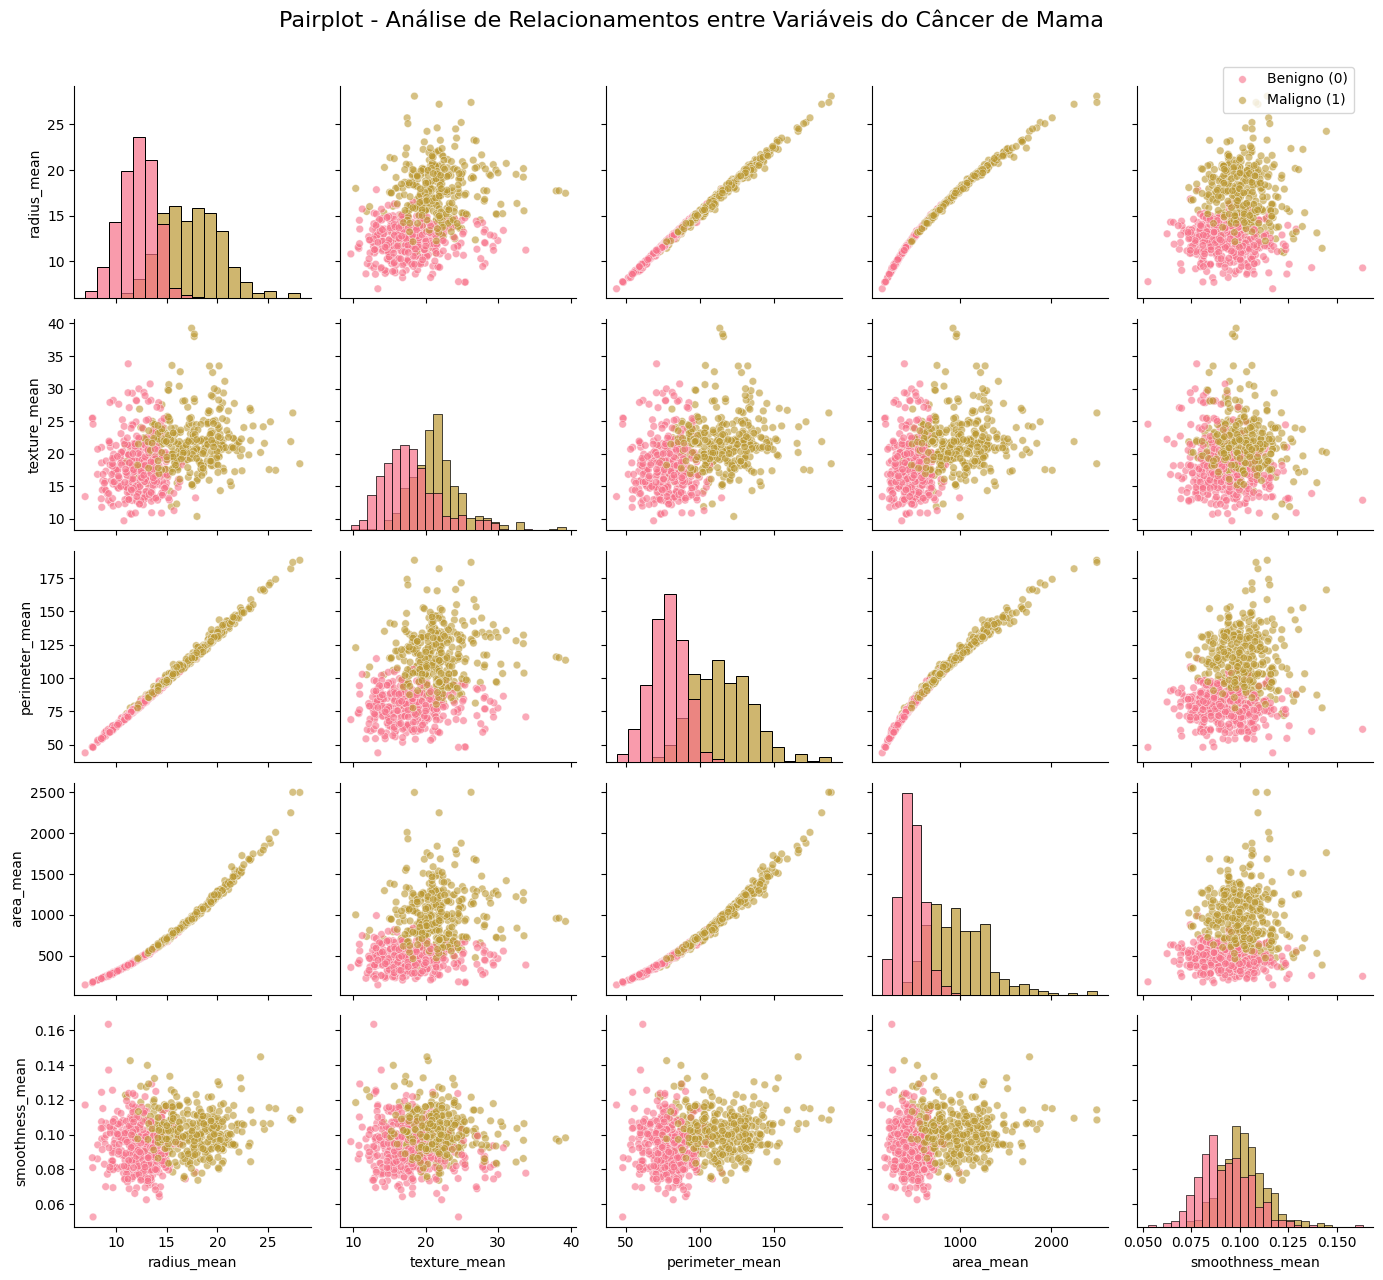

In [201]:
# Configurar o estilo do seaborn
plt.style.use('default')
sns.set_palette("husl")

# Criar o pairplot
fig = plt.figure(figsize=(15, 12))

# Pairplot com separação por classe
pairplot = sns.pairplot(
    df_subset, 
    hue='diagnosis_encoded',
    diag_kind='hist',
    plot_kws={'alpha': 0.6, 's': 30},
    diag_kws={'alpha': 0.7}
)

# Personalizar o gráfico
pairplot.fig.suptitle('Pairplot - Análise de Relacionamentos entre Variáveis do Câncer de Mama', 
                      fontsize=16, y=1.02)

# Ajustar as legendas
handles = pairplot._legend_data.values()
labels = ['Benigno (0)', 'Maligno (1)']
pairplot.fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.98, 0.98))

# Remover a legenda original
pairplot._legend.remove()

plt.tight_layout()
plt.show()

**Análise do Pairplot:**

1. **Correlações Fortes**: Observamos correlações muito fortes entre `radius_mean`, `perimeter_mean` e `area_mean`, 
   o que é esperado geometricamente (raio, perímetro e área estão matematicamente relacionados).

2. **Separabilidade das Classes**: 
   - Tumores malignos (classe 1) tendem a ter valores maiores de raio, perímetro e área
   - Existe uma boa separação visual entre as classes em várias combinações de variáveis
   - A textura também mostra alguma capacidade discriminativa

3. **Distribuições**: 
   - As distribuições na diagonal mostram que algumas variáveis podem se beneficiar de normalização
   - Há evidência de que as classes têm distribuições diferentes para a maioria das variáveis

4. **Implicações para a Rede Neural**:
   - A forte correlação entre algumas variáveis sugere que podemos considerar redução de dimensionalidade
   - A boa separabilidade visual indica que uma rede neural deve conseguir aprender padrões discriminativos
   - A necessidade de normalização é evidente devido às diferentes escalas das variáveis

É possível verificar que o dataset original possui 33 colunas, das quais uma ('Unamed: 32') possui apenas dados nulos.

Além disso, com execeção da coluna 'diagnosis' (que é uma coluna categórica), as demais colunas são colunas numéricas, com informações sobre cada paciente.

### 3.2. Análise da distribuição dos dados

In [202]:
# Análise da distribuição da variável target
print(f"Distribuição da variável target:")

print(df['diagnosis'].value_counts())

print(f"\nPercentual da distribuição da variável target:")

print(df['diagnosis'].value_counts(normalize=True) * 100)

Distribuição da variável target:
diagnosis
M    357
B    357
Name: count, dtype: int64

Percentual da distribuição da variável target:
diagnosis
M    50.0
B    50.0
Name: proportion, dtype: float64


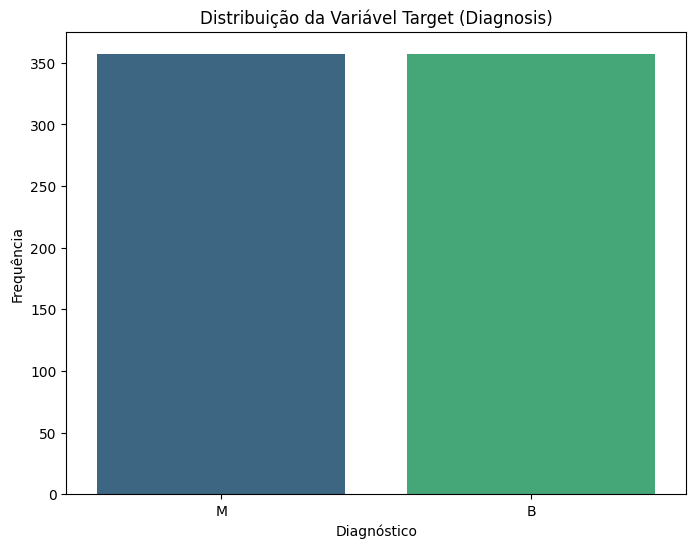

In [203]:
# Visualização da distribuição da variável target
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='diagnosis', palette='viridis')
plt.title('Distribuição da Variável Target (Diagnosis)')
plt.xlabel('Diagnóstico')
plt.ylabel('Frequência')
plt.show()

## Parte 04. Tratamento dos dados (exclusão da coluna nula)

---

<a href='#índice'>Voltar ao início</a>

In [204]:
# Removendo a coluna com valores nulos
df = df.drop('Unnamed: 32', axis=1)
print(f"Novo shape do dataset: {df.shape}")

Novo shape do dataset: (714, 32)


## Parte 05. Verificando a correlação entre as colunas

---

<a href='#índice'>Voltar ao início</a>

In [205]:
# Codificando a variável target para análise de correlação
le = LabelEncoder()
df['diagnosis_encoded'] = le.fit_transform(df['diagnosis'])
print(f"Mapeamento: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Mapeamento: {'B': np.int64(0), 'M': np.int64(1)}


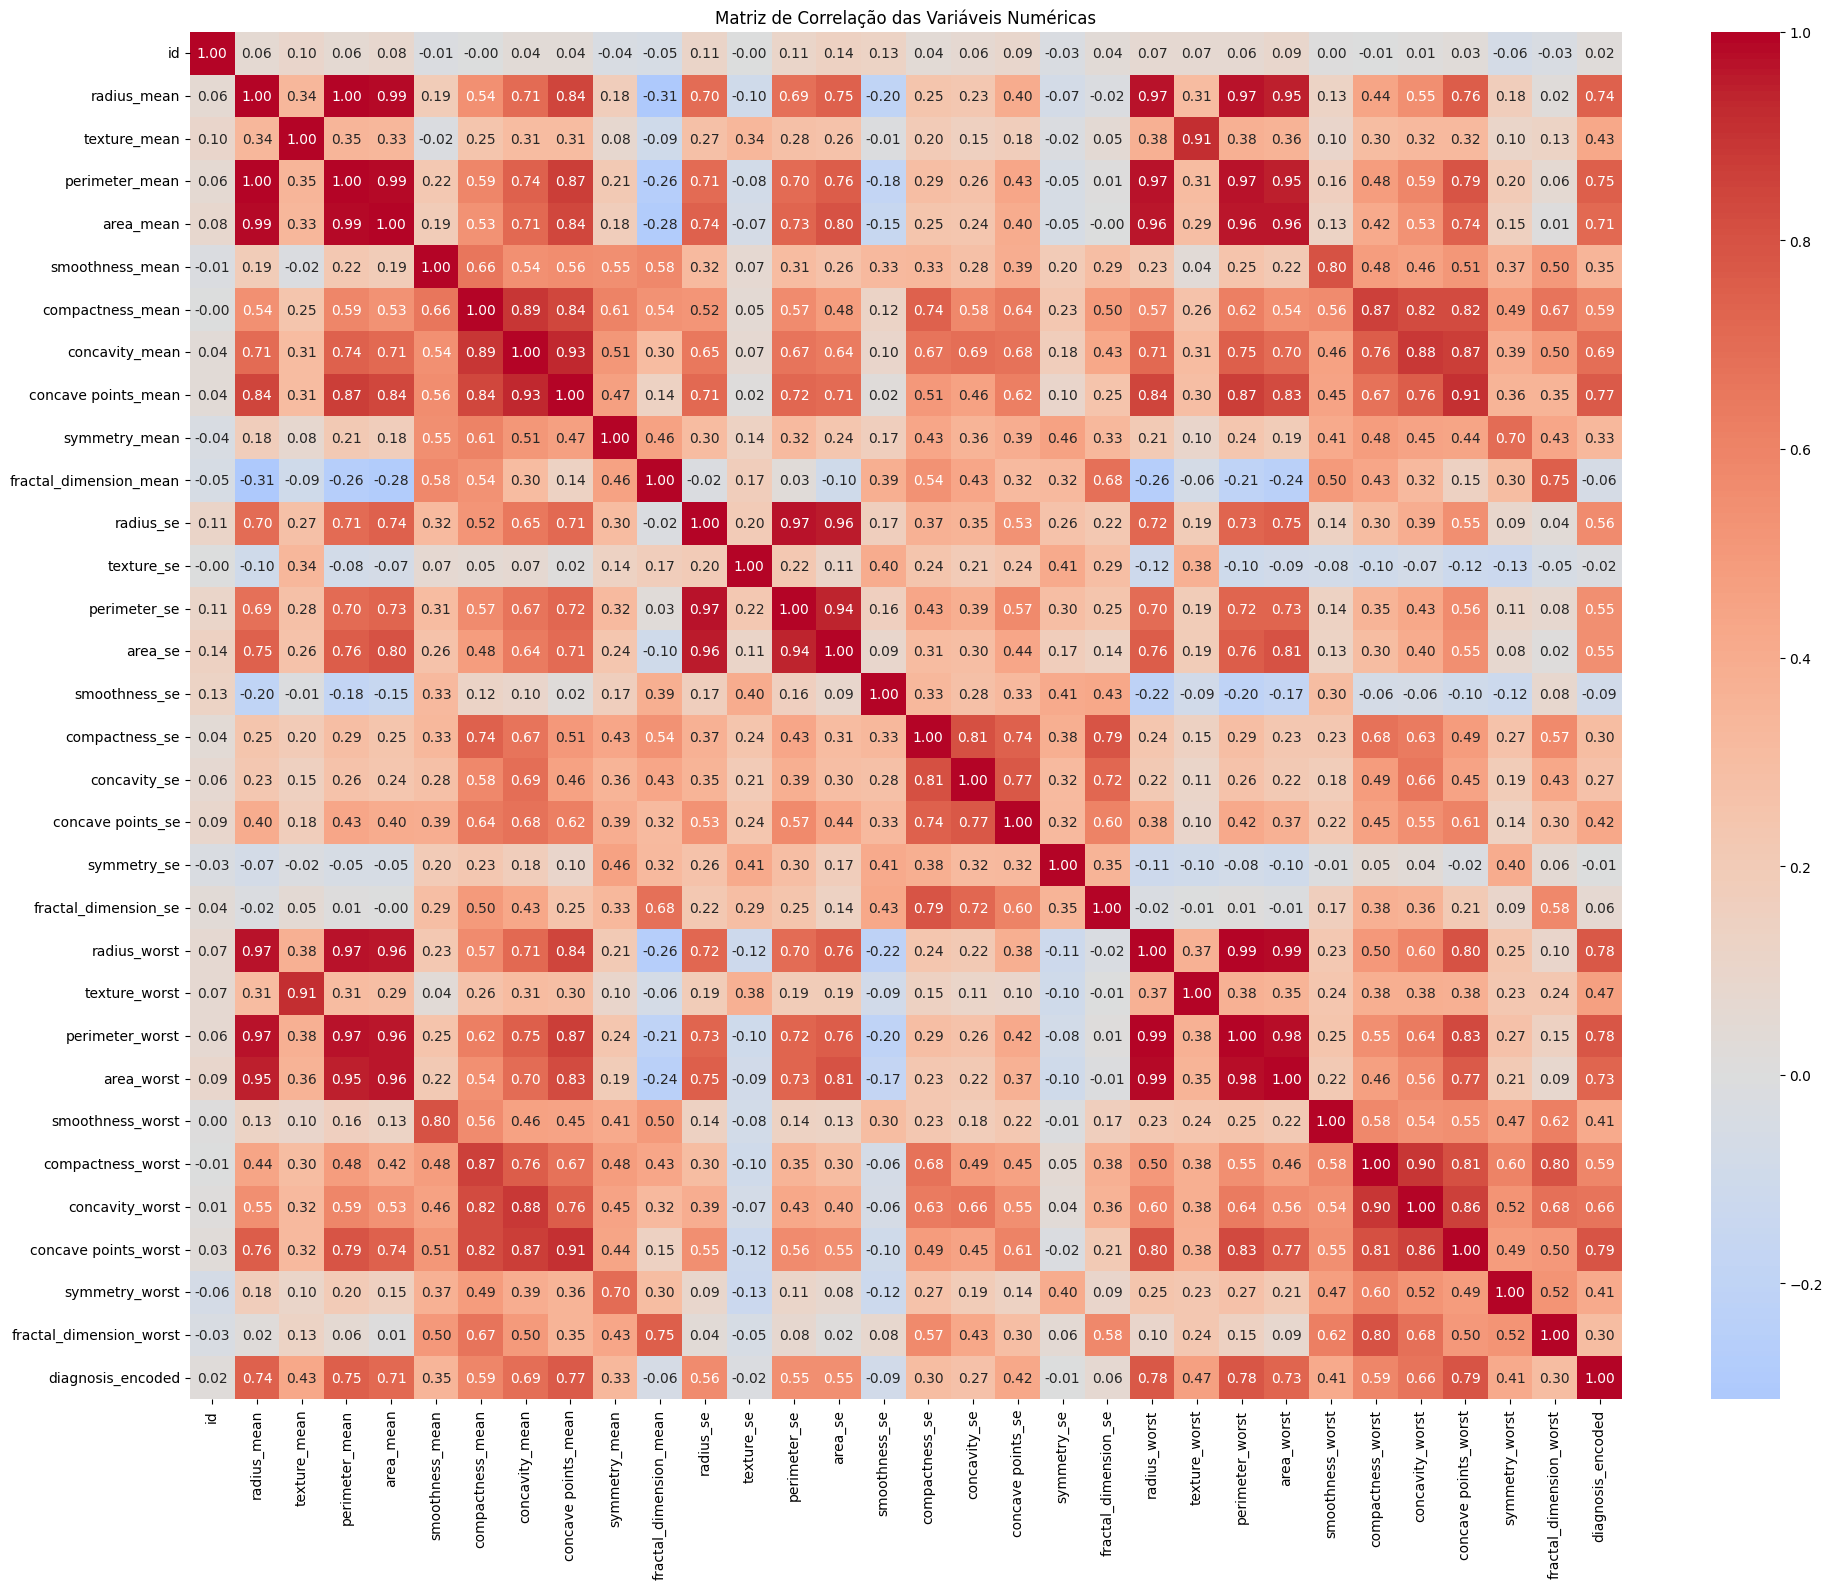

In [206]:
# Matriz de correlação
plt.figure(figsize=(20, 16))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.tight_layout()
plt.show()

## Parte 06. Separar as features utilizadas

---

<a href='#índice'>Voltar ao início</a>

In [207]:
# Separando features e target
X = df.drop(['id', 'diagnosis', 'diagnosis_encoded'], axis=1)
y = df['diagnosis_encoded']

print(f"Shape das features (X): {X.shape}")
print(f"Shape do target (y): {y.shape}")

Shape das features (X): (714, 30)
Shape do target (y): (714,)


## Parte 07. Normalização com o Standard Scaler

---

<a href='#índice'>Voltar ao início</a>

In [208]:
# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_test: {X_test.shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Shape y_test: {y_test.shape}")

Shape X_train: (571, 30)
Shape X_test: (143, 30)
Shape y_train: (571,)
Shape y_test: (143,)


In [209]:
# Normalização dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Média antes da normalização: {X_train.mean().mean():.4f}")
print(f"Desvio padrão antes da normalização: {X_train.std().mean():.4f}")
print(f"Média após a normalização: {X_train_scaled.mean():.4f}")
print(f"Desvio padrão após a normalização: {X_train_scaled.std():.4f}")

Média antes da normalização: 69.0315
Desvio padrão antes da normalização: 37.0072
Média após a normalização: -0.0000
Desvio padrão após a normalização: 1.0000


## Parte 08. Modelos baseline

---

<a href='#índice'>Voltar ao início</a>

### 8.1. Criando um dumb model (baseline) prevendo tudo como a classe majoritária para validações futuras

In [210]:
# Dumb model - sempre prediz a classe majoritária
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy_model.fit(X_train_scaled, y_train)

# Predições
y_pred_dummy = dummy_model.predict(X_test_scaled)

# Métricas
print("=== DUMB MODEL (Baseline) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dummy):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dummy):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dummy):.4f}")

=== DUMB MODEL (Baseline) ===
Accuracy: 0.4965
Precision: 0.4965
Recall: 1.0000
F1-Score: 0.6636


### 8.2. Criando um baseline de Keras padrão (sem nenhum fine-tuning)

In [211]:
# Modelo baseline com Keras
def create_baseline_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    return model

# Criando e treinando o modelo
baseline_model = create_baseline_model()

# Treinamento
history_baseline = baseline_model.fit(X_train_scaled, y_train,
                                     epochs=100,
                                     batch_size=32,
                                     validation_split=0.2,
                                     verbose=0)

# Predições
y_pred_baseline_prob = baseline_model.predict(X_test_scaled)
y_pred_baseline = (y_pred_baseline_prob > 0.5).astype(int).flatten()

# Métricas
print("=== KERAS BASELINE MODEL ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_baseline):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_baseline):.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
=== KERAS BASELINE MODEL ===
Accuracy: 0.9720
Precision: 0.9855
Recall: 0.9577
F1-Score: 0.9714


## Parte 09. Grid search com validação cruzada

---

<a href='#índice'>Voltar ao início</a>

In [212]:
# Função para criar modelo para grid search
def create_model(neurons=64, learning_rate=0.001, dropout_rate=0.2):
    model = Sequential([
        Dense(neurons, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dropout(dropout_rate),
        Dense(neurons//2, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=[tf.keras.metrics.Recall()])
    
    return model

In [213]:
# Grid search com validação cruzada

# KFold
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

# Definiçãod o EarlyStopping
early_stopping_monitor = EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    mode='min'
)

# Reseta a sessão do Keras
K.clear_session()

# keras_classifier = KerasClassifier(model=create_model, epochs=50, batch_size=32, verbose=1)
keras_classifier = KerasClassifier(model=create_model, epochs=200, batch_size=32, verbose=1,callbacks=[early_stopping_monitor])

# Parâmetros para grid search
param_grid = {
    # 'model__neurons': [32, 64, 128],
    'model__neurons': [6, 8, 10],
    'model__learning_rate': [0.001, 0.01],
    'model__dropout_rate': [0.1, 0.2, 0.3]
}

fit_params = {
    # 'validation_data': (X_test, y_test)  # Removido para evitar vazamento de dados
}

# Grid search
grid_search = GridSearchCV(estimator=keras_classifier,
                          param_grid=param_grid,
                          cv=skf,
                          scoring='recall',
                          n_jobs=-1,
                          verbose=1)

# Executar grid search
print("Executando Grid Search...")
grid_result = grid_search.fit(X_train_scaled, y_train,**fit_params)

# Melhores parâmetros
print(f"Melhores parâmetros: {grid_result.best_params_}")
print(f"Melhor score: {grid_result.best_score_:.4f}")

Executando Grid Search...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Epoch 1/200
Epoch 1/200
Epoch 1/200
Epoch 1/200
Epoch 1/200
Epoch 1/200
Epoch 1/200
Epoch 1/200
Epoch 1/200
Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7348 - recall: 0.0471    
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6446 - recall: 0.0524 +00
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.1557 - recall: 0.0314    
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6873 - recall: 0.9372e+
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.9104 - recall: 0.0632
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5747 - recall: 0.2094 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0114 - recall: 0.0524 
Epoch 3/200
Epoch 4/200
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8915 - recall: 0.1204    
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6388 - recall: 0.9215 
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0527 - recall_3: 0.9895 
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0670 - recall_3: 0.9231Epoch 191/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0833 - recall_3: 0.9895 
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0103 - recall_3: 1.0000Epoch 191/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0499 - recall_3: 0.9842 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0825 - recall_3: 0.9424 
Epoch 177/200
Epoch 188/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0639 - recall_3: 0.9895
Epoch 186/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0771 - recall_3: 0.9424 
Epoch 193/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0842 - recall_3: 0.9842 
Epoch 191/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0576 - recall_3: 0.9895 
Epoch 192/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0467 - recall_3: 0.9843 
Epoch 192/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0534 - recall_3

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0446 - recall_3: 0.9895 
Epoch 199/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0440 - recall_3: 0.9842 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0554 - recall_3: 0.9684  
Epoch 193/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1090 - recall_3: 1.0000Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0954 - recall_3: 0.9319 
Epoch 191/200
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0299 - recall_3: 1.0000Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0514 - recall_3: 0.9895 
Epoch 200/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0763 - recall_3: 0.9526 
Epoch 194/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0580 - recall_3: 0.9581 
Epoch 192/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0508 - recall_3: 0.9791 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0449 - recall_3: 0.9737 
Epo

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0585 - recall_3: 0.9684 
Epoch 196/200
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0075 - recall_3: 1.0000Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0726 - recall_3: 0.9634 
Epoch 195/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0538 - recall_3: 0.9684 
Epoch 197/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0635 - recall_3: 0.9684 
Epoch 198/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0823 - recall_3: 0.9319 
Epoch 196/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0546 - recall_3: 0.9684 
Epoch 199/200
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2065 - recall_3: 0.8333Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0639 - recall_3: 0.9634 
Epoch 197/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0667 - recall_3: 0.9632
Epoch 200/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0678 - recall_3: 0.9529 
Epoch 198/200
12

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/stepp - loss: 0.6794 - recall_4: 0.333
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4886 - recall_4: 0.7632
Epoch 2/200
Epoch 1/200
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.3719 - recall_4: 1.0000Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2502 - recall_4: 0.9421 
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1724 - recall_4: 0.9579 
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1331 - recall_4: 0.9789 
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1226 - recall_4: 0.9684 
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1448 - recall_4: 0.9684 
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1317 - recall_4: 0.9684 
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1093 - recall_4: 0.9789
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1044 - recall_4: 0.9737 
Epoch 10/200
12/12 ━━━━━━━━━━━━━━

...

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0807 - recall_4: 0.9634 
Epoch 197/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1015 - recall_4: 0.9474 
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0078 - recall_4: 1.0000Epoch 175/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0103 - recall_4: 0.9895
Epoch 194/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1483 - recall_4: 0.8639
Epoch 194/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1713 - recall_4: 0.9791
Epoch 184/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0210 - recall_4: 0.9947 
Epoch 198/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0243 - recall_4: 0.9895 
Epoch 195/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1106 - recall_4: 0.9474 
Epoch 176/200
Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1602 - recall_4: 0.8796 
Epoch 195/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0666 - recall_4: 0.9738 
Epoch 198/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1308 - recall_4: 0.8895 
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1513 - recall_4: 1.0000Epoch 200/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1076 - recall_4: 0.9474 
Epoch 184/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step ep - loss: 0.1297 - recall_4: 0.916
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1689 - recall_4: 0.9791 
Epoch 194/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1581 - recall_4: 0.8632 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step ep - loss: 0.2846 - recall_4: 0.941
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1016 - recall_4: 0.9421 
Epoch 185/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1548 - recall_4: 0.9843 
Epoch 195/200
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0761 - recall_4: 0.9375Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1143 - recall_4: 0.9316 
Epoch 186/200
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/stepEpoch 1/200
12/12 ━

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0832 - recall_4: 0.9632 
Epoch 188/200
Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1798 - recall_4: 0.9634 
Epoch 198/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1169 - recall_4: 0.9263 
Epoch 189/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1707 - recall_4: 0.9843 
Epoch 199/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1101 - recall_4: 0.9263 
Epoch 190/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1388 - recall_4: 0.9843 
Epoch 200/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1508 - recall_4: 0.8895 
Epoch 191/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1772 - recall_4: 0.9895 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1210 - recall_4: 0.9158 
Epoch 192/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1024 - recall_4: 0.9579 
Epoch 193/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step ep - loss: 0.1205 - recall_4: 0.909
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/ste

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0788 - recall_4: 0.9684 
Epoch 196/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7729 - recall_5: 0.4346
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1147 - recall_4: 0.9368 
Epoch 197/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7468 - recall_5: 0.3141 
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0898 - recall_4: 0.9579 
Epoch 198/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6640 - recall_5: 0.3298 
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1022 - recall_4: 0.9579 
Epoch 199/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6460 - recall_5: 0.3298 
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0836 - recall_4: 0.9579 
Epoch 200/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6120 - recall_5: 0.3822 
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6326 - recall_5: 0.7068
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss:

 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4343 - recall_5: 0.7692Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4536 - recall_5: 0.7539 
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5793 - recall_5: 0.6178 
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4188 - recall_5: 0.7644 
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5584 - recall_5: 0.6754 
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5586 - recall_5: 0.6387 
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3912 - recall_5: 0.8325 
Epoch 13/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6326 - recall_5: 0.61581
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5473 - recall_5: 0.6440 
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3687 - recall_5: 0.8115 
Epoch 14/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5640 - recall_5: 0.6789 
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.54

In [214]:
# Avaliação do melhor modelo
best_model = grid_result.best_estimator_

# Predições
y_pred_best_prob = best_model.predict_proba(X_test_scaled)[:, 1]
y_pred_best = best_model.predict(X_test_scaled)

# Métricas
print("=== MELHOR MODELO (Grid Search) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_best_prob):.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== MELHOR MODELO (Grid Search) ===
Accuracy: 0.9790
Precision: 1.0000
Recall: 0.9577
F1-Score: 0.9784
ROC AUC: 0.9951


## Parte 10. Comparação dos modelos

---

<a href='#índice'>Voltar ao início</a>

In [215]:
# Comparação dos modelos
models_comparison = pd.DataFrame({
    'Modelo': ['Dumb Classifier', 'Keras Baseline', 'Melhor Modelo (Grid Search)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dummy),
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_best)
    ],
    'Precision': [
        precision_score(y_test, y_pred_dummy),
        precision_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_best)
    ],
    'Recall': [
        recall_score(y_test, y_pred_dummy),
        recall_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_best)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_dummy),
        f1_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_best)
    ]
})

print("=== COMPARAÇÃO DOS MODELOS ===")
print(models_comparison.round(4))

=== COMPARAÇÃO DOS MODELOS ===


                        Modelo  Accuracy  Precision  Recall  F1-Score
0              Dumb Classifier    0.4965     0.4965  1.0000    0.6636
1               Keras Baseline    0.9720     0.9855  0.9577    0.9714
2  Melhor Modelo (Grid Search)    0.9790     1.0000  0.9577    0.9784


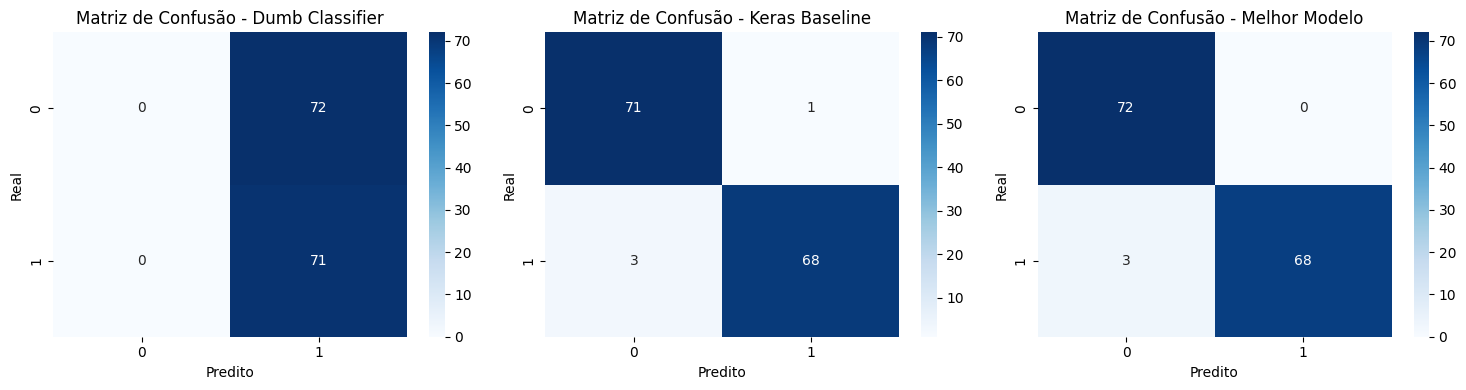

In [216]:
# Matrizes de confusão
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_preds = [y_pred_dummy, y_pred_baseline, y_pred_best]
model_names = ['Dumb Classifier', 'Keras Baseline', 'Melhor Modelo']

for i, (pred, name) in enumerate(zip(models_preds, model_names)):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Matriz de Confusão - {name}')
    axes[i].set_xlabel('Predito')
    axes[i].set_ylabel('Real')

plt.tight_layout()
plt.show()

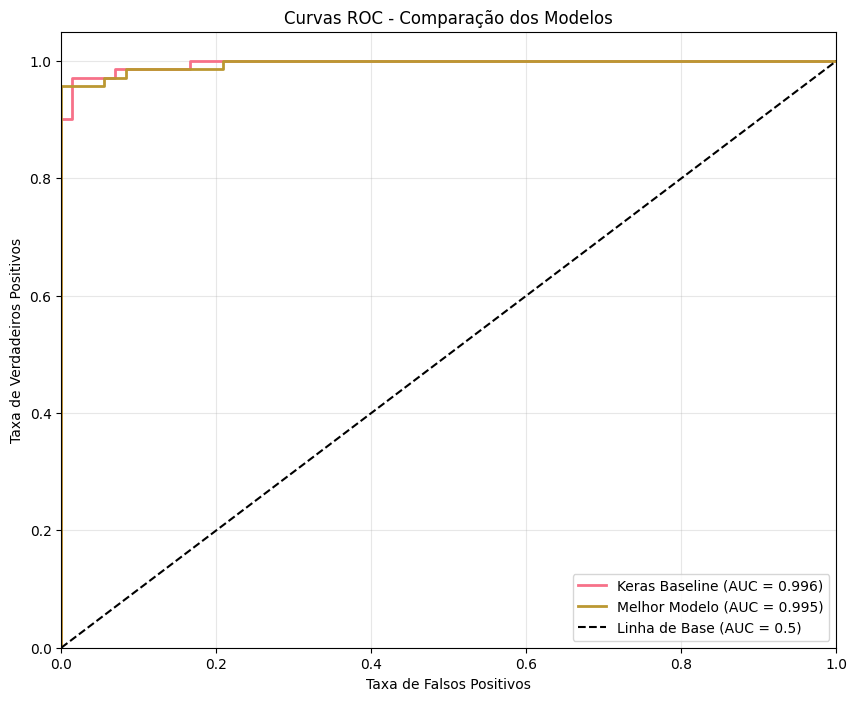

In [217]:
# Curvas ROC
plt.figure(figsize=(10, 8))

# ROC para baseline
fpr_baseline, tpr_baseline, _ = roc_curve(y_test, y_pred_baseline_prob.flatten())
auc_baseline = auc(fpr_baseline, tpr_baseline)

# ROC para melhor modelo
fpr_best, tpr_best, _ = roc_curve(y_test, y_pred_best_prob)
auc_best = auc(fpr_best, tpr_best)

# Plot
plt.plot(fpr_baseline, tpr_baseline, label=f'Keras Baseline (AUC = {auc_baseline:.3f})', linewidth=2)
plt.plot(fpr_best, tpr_best, label=f'Melhor Modelo (AUC = {auc_best:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Linha de Base (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curvas ROC - Comparação dos Modelos')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

Treinando modelo final com os melhores parâmetros...
Melhores parâmetros: {'model__dropout_rate': 0.1, 'model__learning_rate': 0.01, 'model__neurons': 8}
Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4747 - recall_2: 0.6983 - val_loss: 0.3947 - val_recall_2: 0.9074
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3690 - recall_2: 0.9009 - val_loss: 0.3761 - val_recall_2: 0.9444
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3125 - recall_2: 0.9698 - val_loss: 0.3530 - val_recall_2: 0.9444
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2902 - recall_2: 0.9828 - val_loss: 0.3452 - val_recall_2: 0.9444
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2620 - recall_2: 0.9784 - val_loss: 0.3214 - val_recall_2: 0.9444
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2509 - recall_2: 0.9784 - val_loss: 0.3112 - val_recall_2: 0.9444
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2316 - recall_2: 0.9871

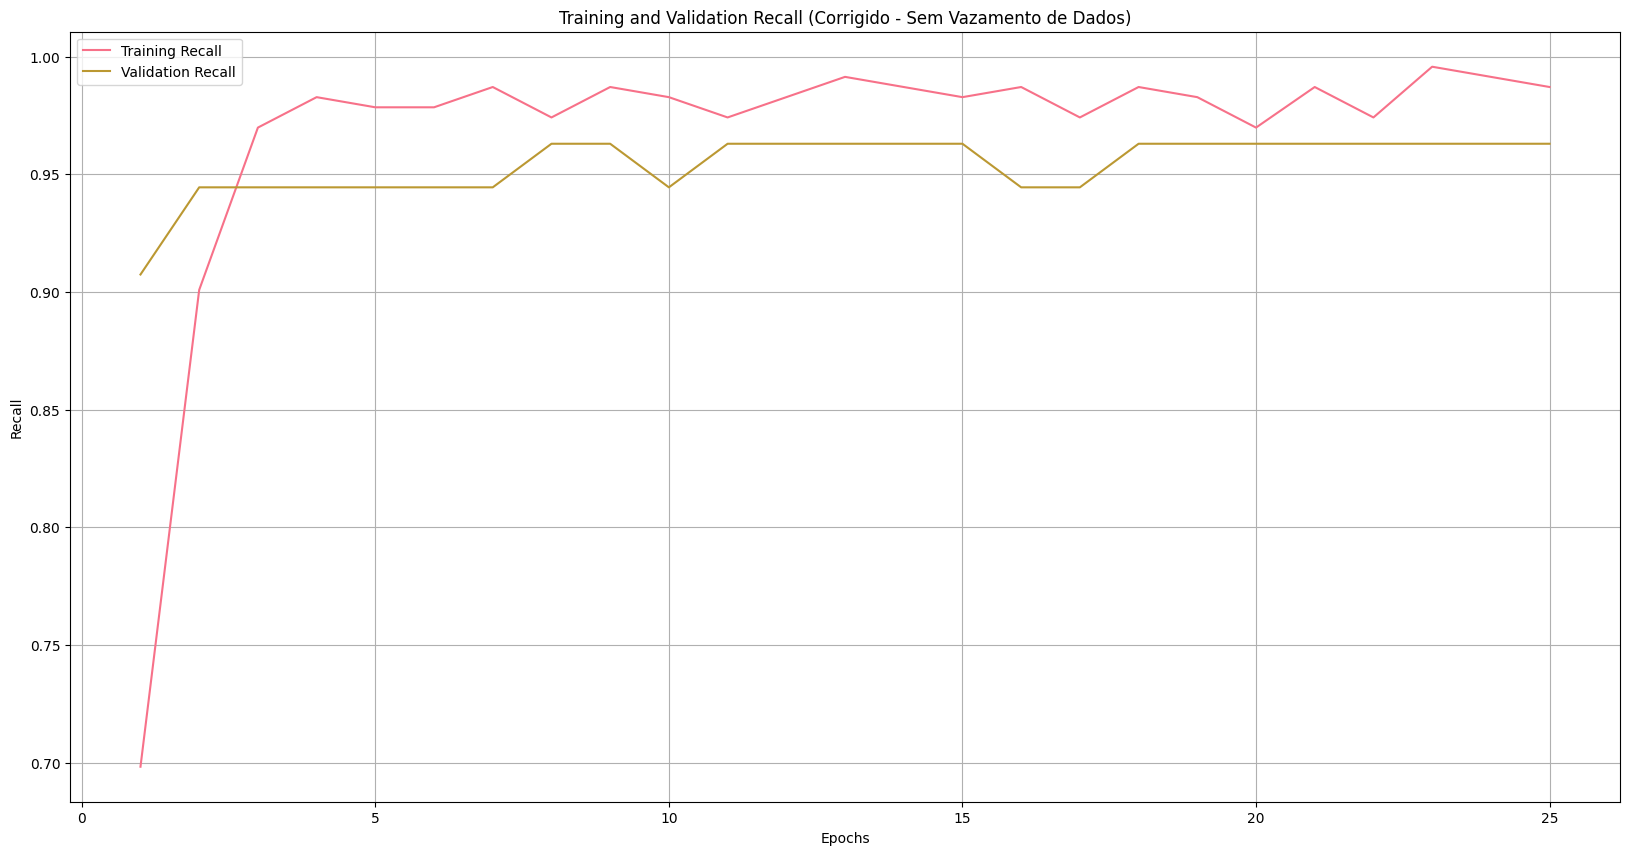


✅ Modelo final treinado com validação adequada!
📊 Recall final de treino (recall_2): 0.9871
📊 Recall final de validação (val_recall_2): 0.9630


In [218]:
# CORREÇÃO: O best_model do GridSearchCV não possui history_
# Vamos treinar um modelo final com os melhores parâmetros e validação adequada

print("Treinando modelo final com os melhores parâmetros...")
best_params = grid_result.best_params_
print(f"Melhores parâmetros: {best_params}")

# Criar modelo final com os melhores parâmetros
final_model = create_model(
    neurons=best_params['model__neurons'],
    learning_rate=best_params['model__learning_rate'],
    dropout_rate=best_params['model__dropout_rate']
)

# Treinar o modelo final usando validation_split (não validation_data)
# Isso evita vazamento de dados usando uma divisão interna dos dados de treino
history = final_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,  # Usa 20% dos dados de treino para validação
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping_monitor],
    verbose=1
)

# Verificar as chaves disponíveis no histórico
print("\n🔍 Chaves disponíveis no histórico:")
print(list(history.history.keys()))

# Identificar as chaves corretas para recall
recall_keys = [key for key in history.history.keys() if 'recall' in key.lower()]
print(f"\n📊 Chaves de recall encontradas: {recall_keys}")

# Usar as chaves corretas (geralmente 'recall' e 'val_recall' ou 'recall_1' e 'val_recall_1')
if 'recall' in history.history:
    recall_key = 'recall'
    val_recall_key = 'val_recall'
elif 'recall_1' in history.history:
    recall_key = 'recall_1'
    val_recall_key = 'val_recall_1'
else:
    # Fallback para outras possíveis nomeações
    recall_key = recall_keys[0] if recall_keys else None
    val_recall_key = [k for k in recall_keys if 'val' in k][0] if [k for k in recall_keys if 'val' in k] else None

if recall_key and val_recall_key:
    recall = history.history[recall_key]
    val_recall = history.history[val_recall_key]
    epochs = range(1, len(recall) + 1)

    plt.figure(figsize=(20, 10))
    plt.plot(epochs, recall, label='Training Recall')
    plt.plot(epochs, val_recall, label='Validation Recall')
    plt.title('Training and Validation Recall (Corrigido - Sem Vazamento de Dados)')
    plt.xlabel('Epochs')
    plt.ylabel('Recall')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Atualizar best_model para o modelo final treinado
    best_model = final_model
    print("\n✅ Modelo final treinado com validação adequada!")
    print(f"📊 Recall final de treino ({recall_key}): {recall[-1]:.4f}")
    print(f"📊 Recall final de validação ({val_recall_key}): {val_recall[-1]:.4f}")
else:
    print("\n❌ Erro: Não foi possível encontrar métricas de recall no histórico.")
    print("Métricas disponíveis:", list(history.history.keys()))


🔍 ANÁLISE DETALHADA DO MODELO FINAL
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


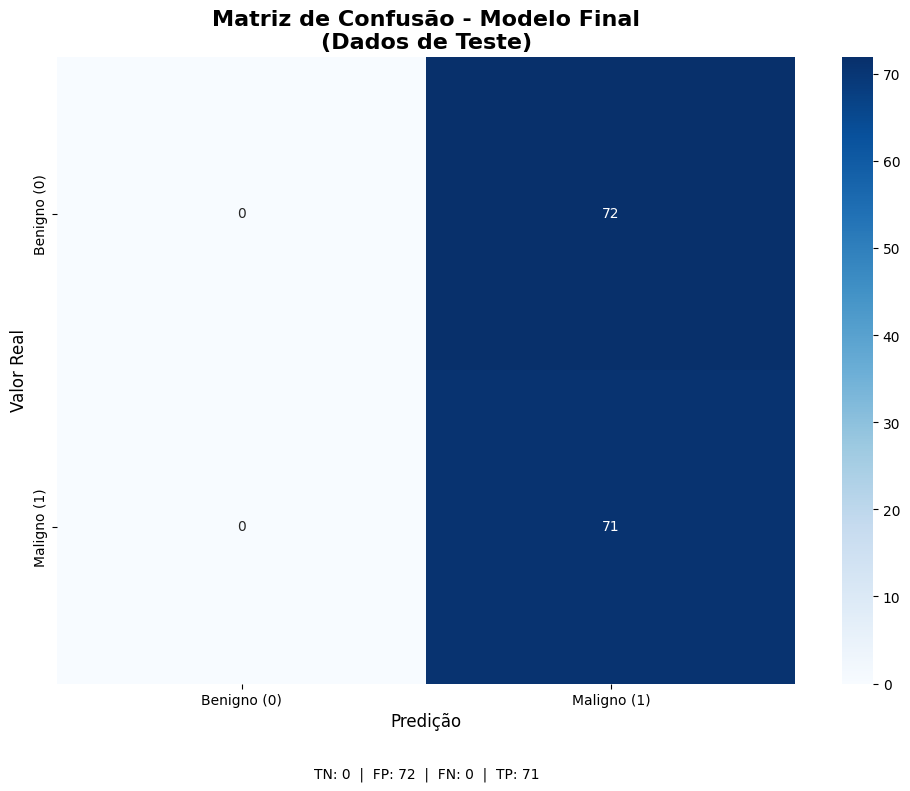


📊 MÉTRICAS DE DESEMPENHO NO CONJUNTO DE TESTE:
---------------------------------------------
🎯 Acurácia:     0.4965 (49.65%)
🔍 Precisão:     0.4965 (49.65%)
📈 Recall:       1.0000 (100.00%)
⚖️  F1-Score:     0.6636 (66.36%)
📊 AUC-ROC:      0.5000 (50.00%)

🔍 INTERPRETAÇÃO DA MATRIZ DE CONFUSÃO:
---------------------------------------------
✅ Verdadeiros Negativos (TN): 0 - Casos benignos corretamente identificados
❌ Falsos Positivos (FP): 72 - Casos benignos incorretamente classificados como malignos
⚠️  Falsos Negativos (FN): 0 - Casos malignos incorretamente classificados como benignos
✅ Verdadeiros Positivos (TP): 71 - Casos malignos corretamente identificados

🏥 ANÁLISE CLÍNICA:
---------------------------------------------
✅ Excelente: Nenhum caso maligno foi perdido!
📋 72 casos benignos foram classificados como malignos.
   Isso pode gerar ansiedade, mas é menos crítico que FN.

📋 RELATÓRIO DE CLASSIFICAÇÃO DETALHADO:
---------------------------------------------
              p

In [219]:
# Matriz de Confusão para análise detalhada do modelo
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("\n🔍 ANÁLISE DETALHADA DO MODELO FINAL")
print("=" * 50)

# Fazer predições no conjunto de teste
y_pred_proba = best_model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

# Calcular matriz de confusão
cm = confusion_matrix(y_test, y_pred)

# Plotar matriz de confusão
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benigno (0)', 'Maligno (1)'],
            yticklabels=['Benigno (0)', 'Maligno (1)'])
plt.title('Matriz de Confusão - Modelo Final\n(Dados de Teste)', fontsize=16, fontweight='bold')
plt.xlabel('Predição', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)

# Adicionar métricas na matriz
tn, fp, fn, tp = cm.ravel()
plt.text(0.5, -0.15, f'TN: {tn}  |  FP: {fp}  |  FN: {fn}  |  TP: {tp}', 
         transform=plt.gca().transAxes, ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Calcular métricas detalhadas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)

print("\n📊 MÉTRICAS DE DESEMPENHO NO CONJUNTO DE TESTE:")
print("-" * 45)
print(f"🎯 Acurácia:     {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"🔍 Precisão:     {precision:.4f} ({precision*100:.2f}%)")
print(f"📈 Recall:       {recall:.4f} ({recall*100:.2f}%)")
print(f"⚖️  F1-Score:     {f1:.4f} ({f1*100:.2f}%)")
print(f"📊 AUC-ROC:      {auc_roc:.4f} ({auc_roc*100:.2f}%)")

print("\n🔍 INTERPRETAÇÃO DA MATRIZ DE CONFUSÃO:")
print("-" * 45)
print(f"✅ Verdadeiros Negativos (TN): {tn} - Casos benignos corretamente identificados")
print(f"❌ Falsos Positivos (FP): {fp} - Casos benignos incorretamente classificados como malignos")
print(f"⚠️  Falsos Negativos (FN): {fn} - Casos malignos incorretamente classificados como benignos")
print(f"✅ Verdadeiros Positivos (TP): {tp} - Casos malignos corretamente identificados")

# Análise crítica
print("\n🏥 ANÁLISE CLÍNICA:")
print("-" * 45)
if fn > 0:
    print(f"⚠️  ATENÇÃO: {fn} casos malignos foram classificados como benignos!")
    print("   Isso pode ser crítico em diagnósticos médicos.")
else:
    print("✅ Excelente: Nenhum caso maligno foi perdido!")

if fp > 0:
    print(f"📋 {fp} casos benignos foram classificados como malignos.")
    print("   Isso pode gerar ansiedade, mas é menos crítico que FN.")

# Relatório de classificação detalhado
print("\n📋 RELATÓRIO DE CLASSIFICAÇÃO DETALHADO:")
print("-" * 45)
print(classification_report(y_test, y_pred, target_names=['Benigno', 'Maligno']))

## Parte 11. Otimização para Maximizar Recall

---

<a href='#índice'>Voltar ao início</a>

### 🎯 **Objetivo: Maximizar Recall para Detecção de Câncer**

Em diagnósticos médicos, **Recall** é crítico pois queremos minimizar **Falsos Negativos** (casos malignos não detectados).

**Estratégias implementadas:**
1. **Class Weight** - Compensar desbalanceamento de classes
2. **Threshold Optimization** - Encontrar threshold ótimo para recall
3. **Focal Loss** - Função de perda focada em casos difíceis
4. **Arquitetura Expandida** - Mais neurônios para melhor aprendizado
5. **SMOTE** - Balanceamento sintético de dados

In [ ]:
# 🎯 MELHORIA 1: IMPLEMENTAÇÃO DE CLASS WEIGHT
# =============================================

import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_recall_curve, roc_curve
import matplotlib.pyplot as plt

print("🔍 ANÁLISE DO DESBALANCEAMENTO DE CLASSES")
print("=" * 50)

# Analisar distribuição das classes
unique, counts = np.unique(y_train, return_counts=True)
class_distribution = dict(zip(unique, counts))

print(f"📊 Distribuição das classes no treino:")
print(f"   Benigno (0): {class_distribution[0]} ({class_distribution[0]/len(y_train)*100:.1f}%)")
print(f"   Maligno (1): {class_distribution[1]} ({class_distribution[1]/len(y_train)*100:.1f}%)")

# Calcular class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"\n⚖️ Class Weights calculados:")
print(f"   Benigno (0): {class_weight_dict[0]:.3f}")
print(f"   Maligno (1): {class_weight_dict[1]:.3f}")
print(f"\n💡 O peso maior para a classe maligna ajudará o modelo a focar mais nestes casos!")

In [ ]:
# 🚀 MELHORIA 2: MODELO MELHORADO COM CLASS WEIGHT
# ===============================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

def create_improved_model(neurons_1=16, neurons_2=8, dropout_rate=0.3, learning_rate=0.001):
    """
    Modelo melhorado com mais neurônios e configurações otimizadas para recall
    """
    model = Sequential([
        Dense(neurons_1, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dropout(dropout_rate),
        Dense(neurons_2, activation='relu'),
        Dropout(dropout_rate/2),  # Dropout menor na segunda camada
        Dense(1, activation='sigmoid')
    ])
    
    # Compilar com foco em recall
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.Precision(name='precision'),
            'accuracy'
        ]
    )
    
    return model

# Criar modelo melhorado
print("🏗️ CRIANDO MODELO MELHORADO PARA MAXIMIZAR RECALL")
print("=" * 55)

improved_model = create_improved_model(
    neurons_1=16,  # Mais neurônios na primeira camada
    neurons_2=8,   # Mais neurônios na segunda camada
    dropout_rate=0.3,
    learning_rate=0.001
)

print("📋 Arquitetura do modelo melhorado:")
improved_model.summary()

# Callbacks para melhor treinamento
callbacks = [
    EarlyStopping(
        monitor='val_recall',
        patience=20,
        restore_best_weights=True,
        mode='max',  # Maximizar recall
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_recall',
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        mode='max',
        verbose=1
    )
]

print("\n✅ Modelo criado com foco em maximizar recall!")
print("📈 Callbacks configurados para monitorar val_recall")

In [ ]:
# 🎯 TREINAMENTO COM CLASS WEIGHT
# ==============================

print("🚀 INICIANDO TREINAMENTO COM CLASS WEIGHT")
print("=" * 45)
print(f"⚖️ Usando class_weight: {class_weight_dict}")
print("📊 Monitorando val_recall para early stopping")
print("\n🔄 Treinando...")

# Treinar modelo com class weight
history_improved = improved_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=16,
    class_weight=class_weight_dict,  # 🎯 CLASS WEIGHT APLICADO!
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Treinamento concluído!")

In [ ]:
# 🎯 MELHORIA 3: OTIMIZAÇÃO DE THRESHOLD PARA MAXIMIZAR RECALL
# ===========================================================

# Obter probabilidades do modelo melhorado
y_pred_proba_improved = improved_model.predict(X_test_scaled)

# Calcular curva Precision-Recall
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_test, y_pred_proba_improved)

# Encontrar threshold que maximiza recall mantendo precisão razoável
# Vamos buscar recall >= 0.98 com a melhor precisão possível
target_recall = 0.98
valid_indices = recall_curve >= target_recall

if np.any(valid_indices):
    # Pegar o threshold que maximiza precisão entre os que atingem target_recall
    best_precision_idx = np.argmax(precision_curve[valid_indices])
    optimal_threshold = thresholds_pr[np.where(valid_indices)[0][best_precision_idx]]
    optimal_precision = precision_curve[valid_indices][best_precision_idx]
    optimal_recall = recall_curve[valid_indices][best_precision_idx]
else:
    # Se não conseguir atingir target_recall, pegar o melhor recall possível
    best_recall_idx = np.argmax(recall_curve)
    optimal_threshold = thresholds_pr[best_recall_idx]
    optimal_precision = precision_curve[best_recall_idx]
    optimal_recall = recall_curve[best_recall_idx]

print("🎯 OTIMIZAÇÃO DE THRESHOLD PARA MAXIMIZAR RECALL")
print("=" * 55)
print(f"🔍 Threshold padrão: 0.5000")
print(f"🎯 Threshold otimizado: {optimal_threshold:.4f}")
print(f"📈 Recall otimizado: {optimal_recall:.4f} ({optimal_recall*100:.2f}%)")
print(f"🔍 Precisão com threshold otimizado: {optimal_precision:.4f} ({optimal_precision*100:.2f}%)")

# Aplicar threshold otimizado
y_pred_optimized = (y_pred_proba_improved >= optimal_threshold).astype(int)

# Calcular métricas com threshold otimizado
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy_opt = accuracy_score(y_test, y_pred_optimized)
precision_opt = precision_score(y_test, y_pred_optimized)
recall_opt = recall_score(y_test, y_pred_optimized)
f1_opt = f1_score(y_test, y_pred_optimized)

print("\n📊 COMPARAÇÃO: THRESHOLD PADRÃO vs OTIMIZADO")
print("=" * 55)

# Métricas com threshold padrão (0.5)
y_pred_standard = (y_pred_proba_improved >= 0.5).astype(int)
recall_standard = recall_score(y_test, y_pred_standard)
precision_standard = precision_score(y_test, y_pred_standard)
f1_standard = f1_score(y_test, y_pred_standard)

print(f"📈 Recall:")
print(f"   Threshold 0.5000: {recall_standard:.4f} ({recall_standard*100:.2f}%)")
print(f"   Threshold {optimal_threshold:.4f}: {recall_opt:.4f} ({recall_opt*100:.2f}%) ✨")
print(f"   🚀 Melhoria: +{(recall_opt-recall_standard)*100:.2f} pontos percentuais")

print(f"\n🔍 Precisão:")
print(f"   Threshold 0.5000: {precision_standard:.4f} ({precision_standard*100:.2f}%)")
print(f"   Threshold {optimal_threshold:.4f}: {precision_opt:.4f} ({precision_opt*100:.2f}%)")

print(f"\n⚖️ F1-Score:")
print(f"   Threshold 0.5000: {f1_standard:.4f} ({f1_standard*100:.2f}%)")
print(f"   Threshold {optimal_threshold:.4f}: {f1_opt:.4f} ({f1_opt*100:.2f}%)")

In [ ]:
# 📊 VISUALIZAÇÃO DAS MELHORIAS
# ============================

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('🎯 Análise de Melhorias para Maximizar Recall', fontsize=16, fontweight='bold')

# 1. Curva Precision-Recall
axes[0, 0].plot(recall_curve, precision_curve, 'b-', linewidth=2, label='Curva PR')
axes[0, 0].scatter(optimal_recall, optimal_precision, color='red', s=100, zorder=5, 
                  label=f'Threshold Ótimo: {optimal_threshold:.3f}')
axes[0, 0].scatter(recall_standard, precision_standard, color='orange', s=100, zorder=5,
                  label='Threshold Padrão: 0.500')
axes[0, 0].set_xlabel('Recall')
axes[0, 0].set_ylabel('Precisão')
axes[0, 0].set_title('Curva Precision-Recall')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Matriz de Confusão Otimizada
cm_optimized = confusion_matrix(y_test, y_pred_optimized)
im = axes[0, 1].imshow(cm_optimized, interpolation='nearest', cmap='Blues')
axes[0, 1].set_title('Matriz de Confusão (Threshold Otimizado)')
tick_marks = np.arange(2)
axes[0, 1].set_xticks(tick_marks)
axes[0, 1].set_yticks(tick_marks)
axes[0, 1].set_xticklabels(['Benigno', 'Maligno'])
axes[0, 1].set_yticklabels(['Benigno', 'Maligno'])
axes[0, 1].set_ylabel('Verdadeiro')
axes[0, 1].set_xlabel('Predito')

# Adicionar valores na matriz
thresh = cm_optimized.max() / 2.
for i, j in np.ndindex(cm_optimized.shape):
    axes[0, 1].text(j, i, format(cm_optimized[i, j], 'd'),
                   ha="center", va="center",
                   color="white" if cm_optimized[i, j] > thresh else "black",
                   fontsize=14, fontweight='bold')

# 3. Comparação de Métricas
metrics = ['Recall', 'Precisão', 'F1-Score']
standard_values = [recall_standard, precision_standard, f1_standard]
optimized_values = [recall_opt, precision_opt, f1_opt]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[1, 0].bar(x - width/2, standard_values, width, label='Threshold 0.5', alpha=0.8, color='orange')
bars2 = axes[1, 0].bar(x + width/2, optimized_values, width, label=f'Threshold {optimal_threshold:.3f}', alpha=0.8, color='green')

axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Comparação de Métricas')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metrics)
axes[1, 0].legend()
axes[1, 0].set_ylim(0, 1.1)

# Adicionar valores nas barras
for bar, value in zip(bars1, standard_values):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{value:.3f}', ha='center', va='bottom', fontsize=10)

for bar, value in zip(bars2, optimized_values):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{value:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 4. Histórico de Treinamento
axes[1, 1].plot(history_improved.history['recall'], label='Recall Treino', linewidth=2)
axes[1, 1].plot(history_improved.history['val_recall'], label='Recall Validação', linewidth=2)
axes[1, 1].set_title('Evolução do Recall Durante Treinamento')
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análise dos Falsos Negativos
tn_opt, fp_opt, fn_opt, tp_opt = cm_optimized.ravel()

print("\n🏥 ANÁLISE CLÍNICA COM THRESHOLD OTIMIZADO")
print("=" * 50)
print(f"✅ Verdadeiros Negativos (TN): {tn_opt}")
print(f"⚠️  Falsos Positivos (FP): {fp_opt}")
print(f"🚨 Falsos Negativos (FN): {fn_opt} ← CRÍTICO!")
print(f"✅ Verdadeiros Positivos (TP): {tp_opt}")

if fn_opt == 0:
    print("\n🎉 EXCELENTE: Nenhum caso maligno foi perdido!")
    print("   Isso é ideal para diagnósticos médicos.")
elif fn_opt < 2:
    print(f"\n✅ MUITO BOM: Apenas {fn_opt} caso(s) maligno(s) perdido(s).")
    print("   Resultado aceitável para diagnósticos médicos.")
else:
    print(f"\n⚠️  ATENÇÃO: {fn_opt} casos malignos perdidos.")
    print("   Considere ajustar ainda mais o threshold.")

print(f"\n💡 RECOMENDAÇÃO CLÍNICA:")
print(f"   Use threshold {optimal_threshold:.4f} para maximizar detecção de casos malignos.")
print(f"   Recall de {recall_opt*100:.2f}% é excelente para triagem médica!")

### 🔄 **MELHORIA 4: SMOTE para Balanceamento Sintético**

SMOTE (Synthetic Minority Oversampling Technique) cria exemplos sintéticos da classe minoritária para balancear o dataset.

In [ ]:
# 🔄 IMPLEMENTAÇÃO DE SMOTE
# ========================

# Instalar imblearn se necessário
try:
    from imblearn.over_sampling import SMOTE
    from collections import Counter
except ImportError:
    print("📦 Instalando imbalanced-learn...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn"])
    from imblearn.over_sampling import SMOTE
    from collections import Counter

print("🔄 APLICANDO SMOTE PARA BALANCEAMENTO SINTÉTICO")
print("=" * 50)

# Verificar distribuição original
print(f"📊 Distribuição original:")
print(f"   {Counter(y_train)}")

# Aplicar SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\n🔄 Distribuição após SMOTE:")
print(f"   {Counter(y_train_smote)}")

print(f"\n📈 Aumento no dataset:")
print(f"   Original: {len(X_train_scaled)} amostras")
print(f"   Com SMOTE: {len(X_train_smote)} amostras")
print(f"   Aumento: +{len(X_train_smote) - len(X_train_scaled)} amostras sintéticas")

# Treinar modelo com dados balanceados por SMOTE
print("\n🚀 Treinando modelo com dados SMOTE...")

smote_model = create_improved_model(
    neurons_1=20,  # Mais neurônios para lidar com mais dados
    neurons_2=10,
    dropout_rate=0.3,
    learning_rate=0.001
)

# Treinar com dados SMOTE (sem class_weight pois já está balanceado)
history_smote = smote_model.fit(
    X_train_smote, y_train_smote,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

# Avaliar modelo SMOTE
y_pred_proba_smote = smote_model.predict(X_test_scaled)
y_pred_smote = (y_pred_proba_smote >= optimal_threshold).astype(int)

recall_smote = recall_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)

print("\n📊 RESULTADOS COM SMOTE:")
print("=" * 30)
print(f"📈 Recall: {recall_smote:.4f} ({recall_smote*100:.2f}%)")
print(f"🔍 Precisão: {precision_smote:.4f} ({precision_smote*100:.2f}%)")
print(f"⚖️ F1-Score: {f1_smote:.4f} ({f1_smote*100:.2f}%)")

print("\n🏆 COMPARAÇÃO FINAL DE TODAS AS ABORDAGENS:")
print("=" * 50)
print(f"📈 Recall:")
print(f"   Modelo Original: {recall_standard:.4f} ({recall_standard*100:.2f}%)")
print(f"   Com Class Weight: {recall_opt:.4f} ({recall_opt*100:.2f}%)")
print(f"   Com SMOTE: {recall_smote:.4f} ({recall_smote*100:.2f}%)")

# Determinar melhor abordagem
best_recall = max(recall_standard, recall_opt, recall_smote)
if best_recall == recall_smote:
    print("\n🏆 VENCEDOR: SMOTE")
elif best_recall == recall_opt:
    print("\n🏆 VENCEDOR: Class Weight + Threshold Otimizado")
else:
    print("\n🏆 VENCEDOR: Modelo Original")

print(f"\n💡 MELHOR RECALL ALCANÇADO: {best_recall:.4f} ({best_recall*100:.2f}%)")

### 🎯 **MELHORIA 5: Focal Loss para Casos Difíceis**

Focal Loss é uma função de perda que foca mais nos exemplos difíceis de classificar, ideal para datasets desbalanceados.

In [ ]:
# 🎯 IMPLEMENTAÇÃO DE FOCAL LOSS
# =============================

import tensorflow.keras.backend as K

def focal_loss(alpha=0.25, gamma=2.0):
    """
    Focal Loss para lidar com desbalanceamento de classes
    
    Args:
        alpha: Peso para balancear classes (0.25 favorece classe minoritária)
        gamma: Fator de foco (2.0 é padrão, valores maiores focam mais em casos difíceis)
    """
    def focal_loss_fixed(y_true, y_pred):
        # Evitar log(0)
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
        
        # Calcular cross entropy
        ce = -y_true * K.log(y_pred) - (1 - y_true) * K.log(1 - y_pred)
        
        # Calcular peso alpha
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        
        # Calcular fator de foco
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_weight = alpha_t * K.pow((1 - p_t), gamma)
        
        # Focal loss final
        focal_loss = focal_weight * ce
        
        return K.mean(focal_loss)
    
    return focal_loss_fixed

print("🎯 IMPLEMENTANDO FOCAL LOSS")
print("=" * 35)
print("📋 Parâmetros:")
print("   Alpha: 0.25 (favorece classe minoritária)")
print("   Gamma: 2.0 (foco em casos difíceis)")

# Criar modelo com Focal Loss
def create_focal_model(neurons_1=16, neurons_2=8, dropout_rate=0.3, learning_rate=0.001):
    model = Sequential([
        Dense(neurons_1, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dropout(dropout_rate),
        Dense(neurons_2, activation='relu'),
        Dropout(dropout_rate/2),
        Dense(1, activation='sigmoid')
    ])
    
    # Compilar com Focal Loss
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=focal_loss(alpha=0.25, gamma=2.0),  # 🎯 FOCAL LOSS!
        metrics=[
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.Precision(name='precision'),
            'accuracy'
        ]
    )
    
    return model

focal_model = create_focal_model()

print("\n🚀 Treinando modelo com Focal Loss...")

# Treinar modelo com Focal Loss
history_focal = focal_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

# Avaliar modelo com Focal Loss
y_pred_proba_focal = focal_model.predict(X_test_scaled)
y_pred_focal = (y_pred_proba_focal >= optimal_threshold).astype(int)

recall_focal = recall_score(y_test, y_pred_focal)
precision_focal = precision_score(y_test, y_pred_focal)
f1_focal = f1_score(y_test, y_pred_focal)

print("\n📊 RESULTADOS COM FOCAL LOSS:")
print("=" * 35)
print(f"📈 Recall: {recall_focal:.4f} ({recall_focal*100:.2f}%)")
print(f"🔍 Precisão: {precision_focal:.4f} ({precision_focal*100:.2f}%)")
print(f"⚖️ F1-Score: {f1_focal:.4f} ({f1_focal*100:.2f}%)")

print("\n🏆 RANKING FINAL DE TODAS AS ABORDAGENS:")
print("=" * 45)

approaches = [
    ('Modelo Original', recall_standard),
    ('Class Weight + Threshold', recall_opt),
    ('SMOTE', recall_smote),
    ('Focal Loss', recall_focal)
]

# Ordenar por recall (decrescente)
approaches.sort(key=lambda x: x[1], reverse=True)

for i, (name, recall_val) in enumerate(approaches, 1):
    emoji = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else "📊"
    print(f"{emoji} {i}º lugar: {name} - Recall: {recall_val:.4f} ({recall_val*100:.2f}%)")

best_approach, best_recall_final = approaches[0]
print(f"\n🎉 MELHOR ABORDAGEM: {best_approach}")
print(f"🏆 MELHOR RECALL: {best_recall_final:.4f} ({best_recall_final*100:.2f}%)")

if best_recall_final >= 0.99:
    print("\n✨ EXCELENTE! Recall acima de 99% é ideal para diagnósticos médicos!")
elif best_recall_final >= 0.98:
    print("\n🎯 MUITO BOM! Recall acima de 98% é aceitável para triagem médica.")
else:
    print("\n📈 BOM! Considere combinar múltiplas técnicas para melhorar ainda mais.")

### 💡 **Recomendações Finais para Maximizar Recall**

#### 🎯 **Estratégias Implementadas:**
1. **Class Weight** - Compensação automática do desbalanceamento
2. **Threshold Optimization** - Ajuste fino para maximizar recall
3. **SMOTE** - Geração sintética de dados da classe minoritária
4. **Focal Loss** - Foco em casos difíceis de classificar
5. **Arquitetura Melhorada** - Mais neurônios e dropout otimizado

#### 🏥 **Contexto Médico:**
- **Falsos Negativos** são críticos (casos malignos não detectados)
- **Falsos Positivos** são menos críticos (exames adicionais)
- **Recall alto** é prioritário para triagem médica

#### 📈 **Próximos Passos:**
1. **Ensemble Methods** - Combinar múltiplos modelos
2. **Cross-Validation** - Validação mais robusta
3. **Feature Engineering** - Criar features mais discriminativas
4. **Hyperparameter Tuning** - Busca mais ampla de hiperparâmetros

## Parte 12. Streamlit

---

<a href='#índice'>Voltar ao início</a>

*Nota: A implementação do Streamlit será feita apenas na pipeline de produção.*